Competition description

Twitter has become an important communication channel in times of emergency. The ubiquitousness of smartphones enables people to announce an emergency they’re observing in real-time. Because of this, more agencies are interested in programatically monitoring Twitter (i.e. disaster relief organizations and news agencies).

But, it’s not always clear whether a person’s words are actually announcing a disaster.

Acknowledgments

This dataset was created by the company figure-eight and originally shared on their ‘Data For Everyone’ website here.



Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import re
import string

Load csv files

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/nlp-getting-started/sample_submission.csv
/kaggle/input/nlp-getting-started/train.csv
/kaggle/input/nlp-getting-started/test.csv


Read files

In [3]:
train  = pd.read_csv('/kaggle/input/nlp-getting-started/train.csv')
test = pd.read_csv('/kaggle/input/nlp-getting-started/test.csv')
submission = pd.read_csv('/kaggle/input/nlp-getting-started/sample_submission.csv')

In [4]:
train

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1
...,...,...,...,...,...
7608,10869,NaN,NaN,Two giant cranes holding a bridge collapse int...,1
7609,10870,NaN,NaN,@aria_ahrary @TheTawniest The out of control w...,1
7610,10871,NaN,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1
7611,10872,NaN,NaN,Police investigating after an e-bike collided ...,1


In [5]:
test

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan
...,...,...,...,...
3258,10861,NaN,NaN,EARTHQUAKE SAFETY LOS ANGELES ÛÒ SAFETY FASTE...
3259,10865,NaN,NaN,Storm in RI worse than last hurricane. My city...
3260,10868,NaN,NaN,Green Line derailment in Chicago http://t.co/U...
3261,10874,NaN,NaN,MEG issues Hazardous Weather Outlook (HWO) htt...


In [6]:
submission

,id,target
0,0,0
1,2,0
2,3,0
3,9,0
4,11,0
...,...,...
3258,10861,0
3259,10865,0
3260,10868,0
3261,10874,0


Analyse train

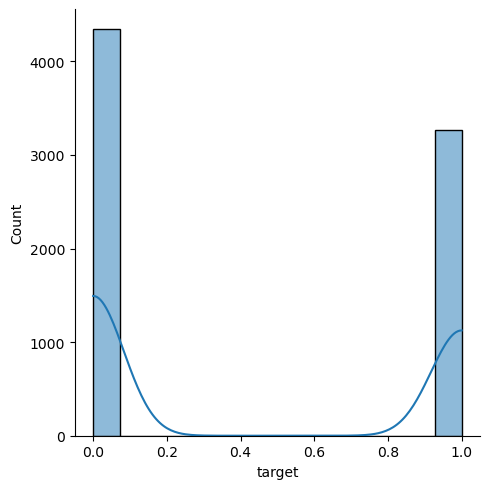

In [7]:
sns.displot(train['target'], kde=True)

In [8]:
train['target'].value_counts()

0    4342
1    3271
Name: target, dtype: int64

In [9]:
num_classes = train['target'].nunique()
print(num_classes)

2


Split dataset

In [10]:
import tensorflow as tf
from tensorflow import keras
import tensorflow_datasets as tfds
from tensorflow.keras import layers
from tensorflow.keras import losses
from keras.models import load_model
from keras.callbacks import ModelCheckpoint, EarlyStopping
print(tf.__version__)

2.11.0


In [11]:
X = train['text']
y = train['target']

X_test = test['text']

In [12]:
# Import functions from sklearn library
from sklearn.model_selection import train_test_split

# Splitting the data into training and testing sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1,random_state=42, shuffle=y)
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((6851,), (762,), (6851,), (762,))

In [13]:
X_train_ds = tf.convert_to_tensor(X_train)
X_val_ds = tf.convert_to_tensor(X_val)
y_train_ds = tf.convert_to_tensor(y_train)
y_val_ds = tf.convert_to_tensor(y_val)

Vectorise tweets

In [14]:
def custom_standardization(input_data):
  lowercase = tf.strings.lower(input_data)
  stripped_html = tf.strings.regex_replace(lowercase, '<\b>' ,' ')
  return tf.strings.regex_replace(stripped_html,'[%s#@]' % re.escape(string.punctuation),'')

In [15]:
max_features = 10000
sequence_length = 250

text_vectorizer = layers.TextVectorization(
    standardize=custom_standardization,
    max_tokens=max_features,
    output_mode='int',
    output_sequence_length=sequence_length)

In [16]:
# Make a text-only dataset (without labels), then call adapt
features = X_train_ds
text_vectorizer.adapt(features)

In [17]:
def preprocess(x):
  return text_vectorizer(x)

Define model

In [18]:
inputs = keras.Input(shape=(1,), dtype='string')
outputs = layers.Dense(1)(preprocess(inputs))
model = keras.Model(inputs, outputs)

In [19]:
model.compile(
    optimizer='adam',
    loss=losses.BinaryCrossentropy(from_logits=True),
    metrics=['accuracy']
    )
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 1)]               0         
                                                                 
 text_vectorization (TextVec  (None, 250)              0         
 torization)                                                     
                                                                 
 dense (Dense)               (None, 1)                 251       
                                                                 
Total params: 251
Trainable params: 251
Non-trainable params: 0
_________________________________________________________________


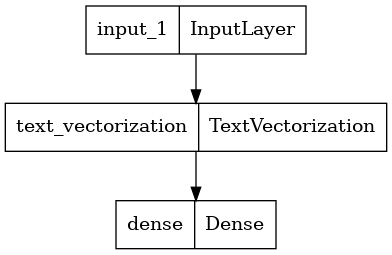

In [20]:
keras.utils.plot_model(model, "sentiment_classifier.png")

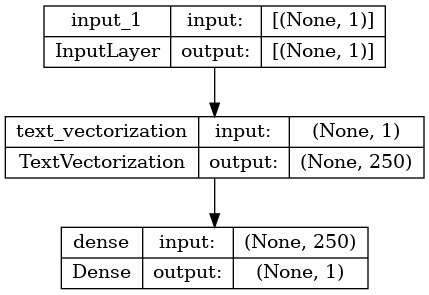

In [21]:
keras.utils.plot_model(model, "sentiment_classifier_with_shape_info.png", show_shapes=True)

In [22]:
epochs = 200

early_stopping = EarlyStopping(monitor='val_loss', mode='min', patience=25, verbose=1)
mc = ModelCheckpoint ('best_model.tf', monitor='val_loss', mode='min', save_best_only=True)

history = model.fit(
    X_train_ds, y_train_ds,
    epochs=epochs,
    validation_data=(X_val_ds, y_val_ds),
    callbacks=[early_stopping, mc],
    verbose=1)

Epoch 1/200
215/215 [==============================] - 3s 11ms/step - loss: 128.5178 - accuracy: 0.5068 - val_loss: 10.4912 - val_accuracy: 0.4869
Epoch 2/200
215/215 [==============================] - 2s 8ms/step - loss: 4.5237 - accuracy: 0.5204 - val_loss: 2.3878 - val_accuracy: 0.5092
Epoch 3/200
215/215 [==============================] - 1s 3ms/step - loss: 2.6800 - accuracy: 0.5123 - val_loss: 2.9596 - val_accuracy: 0.4987
Epoch 4/200
215/215 [==============================] - 1s 4ms/step - loss: 2.9695 - accuracy: 0.5145 - val_loss: 2.4606 - val_accuracy: 0.5249
Epoch 5/200
215/215 [==============================] - 2s 8ms/step - loss: 2.1786 - accuracy: 0.5262 - val_loss: 1.7484 - val_accuracy: 0.5105
Epoch 6/200
215/215 [==============================] - 2s 10ms/step - loss: 2.2299 - accuracy: 0.5218 - val_loss: 1.3247 - val_accuracy: 0.5131
Epoch 7/200
215/215 [==============================] - 1s 3ms/step - loss: 1.9495 - accuracy: 0.5325 - val_loss: 2.2088 - val_accuracy: 0

In [23]:
len(history.history['loss']) 

31

In [24]:
probability_model = keras.Sequential([
                        model, 
                        layers.Activation('sigmoid')
                        ])

In [25]:
y_pred = probability_model.predict(X_val)
y_pred = y_pred.flatten()

24/24 [==============================] - 0s 3ms/step


In [26]:
cutoff = y_pred.max() / 2

y_pred = np.where(y_pred > 0.5, 1, 0)

y_pred

array([0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,

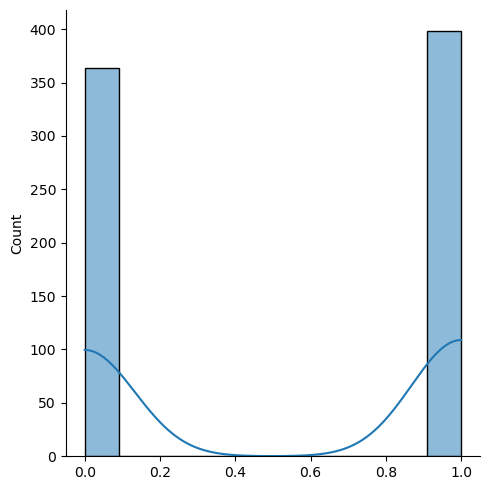

In [27]:
sns.displot(y_pred, kde=True)

In [28]:
from sklearn.metrics import accuracy_score

accuracy_score(y_val, y_pred)

0.49868766404199477

In [29]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_val, y_pred)

array([[204, 222],
       [160, 176]])

In [30]:
model.save('tweet_model')

Make predictions on test set

In [31]:
predictions = probability_model.predict(X_test)
predictions = predictions.flatten()

102/102 [==============================] - 0s 3ms/step


In [32]:
cutoff = predictions.max() / 2

predictions = np.where(predictions > 0.5, 1, 0)

predictions

array([0, 0, 1, ..., 0, 0, 1])

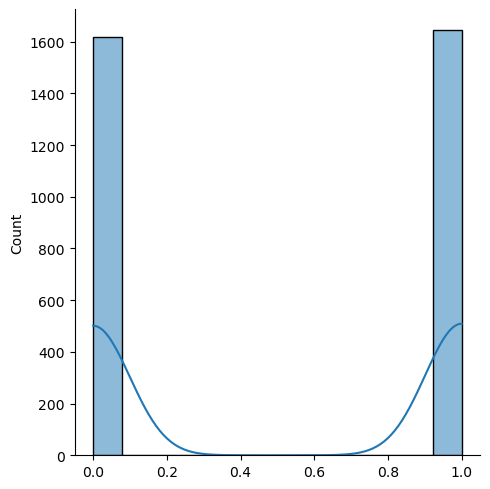

In [33]:
sns.displot(predictions, kde=True)

Prepare submission

In [34]:

submission['target'] = predictions
submission.to_csv('submission.csv',index=False) # writing data to a CSV file
submission = pd.read_csv("submission.csv")
submission


,id,target
0,0,0
1,2,0
2,3,1
3,9,0
4,11,0
...,...,...
3258,10861,0
3259,10865,0
3260,10868,0
3261,10874,0
